In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings("ignore")

seed=2024
np.random.seed(seed)


/home/mind/areyerol/.local/lib/python3.6/site-packages/pkg_resources/__init__.py:119: PkgResourcesDeprecationWarning: 0.18ubuntu0.18.04.1 is an invalid version and will not be supported in a future release
  PkgResourcesDeprecationWarning,


In [2]:
def hypertune_predictor(estimator, X, y, param_grid):
    # param_grid = {"max_depth": [2, 5, 10]}
    grid_search = GridSearchCV(estimator, param_grid=param_grid, cv=2, n_jobs=-1, scoring= 'r2')
    grid_search.fit(X, y)
    # Extract the best model's hyperparameters
    best_hyperparameters = grid_search.best_params_

# Print the best hyperparameters
    print("Best Hyperparameters:", best_hyperparameters)
    return grid_search.best_estimator_, grid_search.best_score_



class CPI_sampler():

    def __init__(
        self,
        estimator=None,
        do_hyper=True,
        dict_hyper=None,
        random_state=2024,
    ):
        self.estimator = estimator
        self.do_hyper = do_hyper
        self.dict_hyper = dict_hyper
        self.random_state = random_state
        random.seed(random_state)
        if dict_hyper==None and estimator == None:
            self.estimator=RandomForestRegressor()
            self.dict_hyper = {
                'n_estimators': [100, 200],  
                'max_depth': [None, 10, 20],  
                'min_samples_split': [2, 10],  
                'min_samples_leaf': [1, 4],  
                'max_features': ['sqrt', 'log2']  
            }
        elif estimator=="nn":
            self.estimator=MLPRegressor()
            self.dict_hyper={
                'hidden_layer_sizes': [(50,), (100,), (50, 50)],
                'activation': ['tanh'],
                #'solver': ['adam', 'sgd'],
                #'alpha': [0.0001, 0.001, 0.01],
                'learning_rate': ['constant', 'adaptive'],
                #'learning_rate_init': [0.001, 0.01],
                #'max_iter': [200, 500]
            }
    
    def fit(self, X, y):
        if self.do_hyper:
            self.estimator, _= hypertune_predictor(self.estimator, X, y, self.dict_hyper)
        else:
            self.estimator= self.estimator.fit(X, y)


    def fit_res(self, X, y):
        X_fitted=self.estimator.predict(X)
        self.residuals=y-X_fitted
    
    def sample(self, X):
        X_fitted=self.estimator.predict(X)
        return X_fitted+random.choices(self.residuals,k= X.shape[0])


In [3]:
# covariance matrice 
def ind(i,j,k):
    # separates &,n into k blocks
    return int(i//k==j//k)
# One Toeplitz matrix  
def toep (d, rho=0.6):
  return np.array([[ (rho)**abs(i-j) for i in range(d)]for j in range(d)])

In [4]:
def GenToysDataset(n=1000, d=10, cor='toep', y_method="imp1", k=2, mu=None, rho_toep=0.6):
    X = np.zeros((n,d))
    y = np.zeros(n)
    if mu is None:
        mu=np.ones(d)
    if cor =='iso': 
        # Generate a simple MCAR distribution, with isotrope observation 
        X= np.random.normal(size=(n,d))
    elif cor =='cor': 
        # Generate a simple MCAR distribution, with anisotropic observations and Sigma=U
        U= np.array([[ind(i,j,k) for j in range(d)] for i in range(d)])/np.sqrt(k)
        X= np.random.normal(size=(n,d))@U+mu
    elif cor =='toep': 
        # Generate un simpler MCAR distribution, with anisotropic observations and Sigma=Toepliz
        X= np.random.multivariate_normal(mu,toep(d, rho_toep),size=n)
    else :
        print("WARNING: key word")
    
    if y_method == "imp1":
        y=X[:,0]*X[:,1]*(X[:,2]>0)+2*X[:,3]*X[:,4]*(0>X[:,2])
    elif y_method == "lin":
        y=X[:,0]-X[:,1]+2*X[:, 2]+ X[:,3]-3*X[:,4]
    else :
        print("WARNING: key word")
    return X, y

## Linear data

In [24]:
X,y=GenToysDataset(n=1000, d=500, cor='toep', y_method="lin", k=2, mu=None, rho_toep=0.6)


scaler = StandardScaler()

# Fit the scaler on the training data


# Transform the test data using the same scaler
X_train_non_scaled, X_test_non_scaled, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
X_train = scaler.fit_transform(X_train_non_scaled)
X_test = scaler.transform(X_test_non_scaled)


In [25]:
modelMLP=MLPRegressor(random_state=seed)

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (50, 50), (100, 100), (50, 50, 50)],
    'activation': ['tanh', 'relu', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': ['auto', 16, 32, 64],
    'momentum': [0.9, 0.95, 0.99]  # Only relevant for 'sgd' solver
}

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  # Simplified to 3 options
    'activation': ['relu', 'tanh'],  # Focus on most common activations
    'solver': ['adam', 'sgd'],  # Keep 2 popular solvers
    'alpha': [0.0001, 0.001, 0.01],  # Narrow alpha range
    'learning_rate': ['constant', 'adaptive'],  # Focus on the most common learning rates
    'learning_rate_init': [0.001, 0.01],  # Two learning rate initialization values
    'batch_size': ['auto', 32],  # Focus on default 'auto' and a smaller value
    'momentum': [0.9, 0.95]  # Only applies to 'sgd', reduced to 2 values
}

modelMLP, MLP_score= hypertune_predictor(modelMLP, X_train, y_train, mlp_param_grid)

print("MLP score: "+str(MLP_score))
modelRF=RandomForestRegressor(random_state=seed)
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 10, 30],  
    'min_samples_split': [2, 10], 
    'min_samples_leaf': [1, 4],  
    'max_features': ['auto', 'sqrt'], 
    'bootstrap': [True] 
}



modelRF, RF_score=hypertune_predictor(modelRF, X_train, y_train, rf_param_grid)

print("RF score: "+str(RF_score))
modelGB= GradientBoostingRegressor(random_state=seed)

gb_param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'subsample': [0.8, 0.9, 1.0],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

gb_param_grid = {
    'n_estimators': [100, 300],  
    'learning_rate': [0.01, 0.1], 
    'max_depth': [3, 7], 
    'min_samples_split': [2, 10],  
    'min_samples_leaf': [1, 4],
    'subsample': [0.8, 1.0], 
    'loss': ['squared_error', 'huber']  
}


modelGB, GB_score=hypertune_predictor(modelGB, X_train, y_train, gb_param_grid)
print("GB score: "+str(GB_score))
modelxgb = XGBRegressor(random_state=seed)

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_param_grid = {
    'n_estimators': [100, 300],  # Reduced to two key values
    'learning_rate': [0.01, 0.1],  # Focus on two typical learning rates
    'max_depth': [3, 7],  # Two key depths to cover shallow and deeper trees
    'min_child_weight': [1, 5],  # Narrowed down to two values
    'subsample': [0.8, 1.0],  # Focus on two common subsample rates
    'colsample_bytree': [0.8, 1.0],  # Same for colsample_bytree
    'gamma': [0, 0.1]  # Reduced to two values for regularization
}



modelxgb, xgb_score=hypertune_predictor(modelxgb, X_train, y_train, xgb_param_grid)

print("XGB score: "+str(xgb_score))

models=[modelMLP, modelRF, modelGB, modelxgb]
scores=[MLP_score, RF_score, GB_score, xgb_score]
max_index = scores.index(max(scores))
print(max_index)
model = models[max_index]
np.mean((y_test-model.predict(X_test))**2)

/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization has

Best Hyperparameters: {'activation': 'tanh', 'alpha': 0.01, 'batch_size': 'auto', 'hidden_layer_sizes': (100,), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'momentum': 0.95, 'solver': 'sgd'}
MLP score: 0.46141844455030984
Best Hyperparameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
RF score: 0.23136552860162157
Best Hyperparameters: {'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.8}
GB score: 0.8734945871363858


/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manyli

Best Hyperparameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
XGB score: 0.8653529081264308
2


0.3579769110063841

In [26]:

d=X_train.shape[1]

y_fitted=model.predict(X_test)
n_test=len(y_test)

df_y_cond_fit = np.zeros((n_test, d))
for j in range(d):
    cpi=CPI_sampler()
    cpi.fit(np.delete(X_train, j, axis=1), X_train[:,j])
    cpi.fit_res(np.delete(X_test, j, axis=1), X_test[:,j])
    X_cond=X_test.copy()
    X_cond[:,j]=cpi.sample(np.delete(X_test, j , axis=1))
    df_y_cond_fit[:, j]=model.predict(X_cond)
    

df_y_test = pd.DataFrame(y_test, columns=['y_test'])  
df_y_fitted = pd.DataFrame(y_fitted, columns=['y_fitted'])
df_y_cond_fit = pd.DataFrame(df_y_cond_fit, columns=[f'coord{i}' for i in range(d)])
# Save to CSV files
df_y_test.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_test-lin500.csv", index=False)
df_y_fitted.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_fitted-lin500.csv", index=False)
df_y_cond_fit.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin500.csv", index=False)





Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'mi

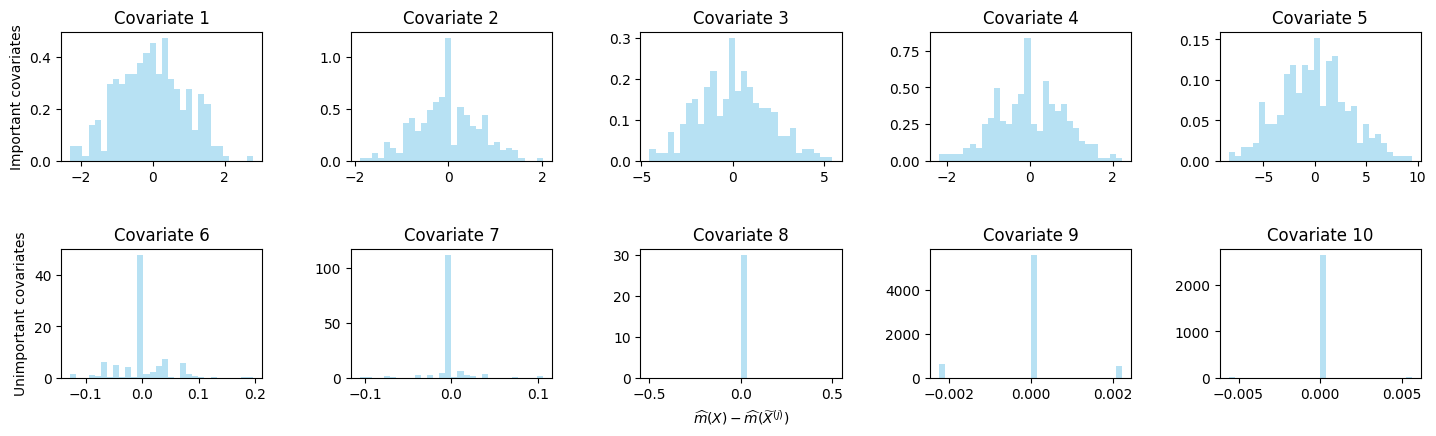

In [27]:
num_cov=10
num_cols=5
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
sign_flip=np.zeros(num_cov)

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin500.csv")

y_fitted = df_y_fitted.values.ravel()  

for i in range(num_cov):
    y_cond_fitted=df_y_cond_fit["coord"+str(i)]
    row = i // num_cols
    col = i % num_cols
    diff=y_fitted-y_cond_fitted
    axes[row, col].hist(diff, bins=30, density=True, color='skyblue', alpha=0.6)
    axes[row, col].set_title(f"Covariate {i+1}")
    
    eps=np.random.choice([-1, 1], size=len(diff))
    ks_statistic, p_value = ks_2samp(diff, eps*diff)
    sign_flip[i]=p_value
axes[1, 2].set_xlabel(r"$\widehat{m}(X)-\widehat{m}(\widetilde{X}^{(j)})$")
axes[0, 0].set_ylabel("Important covariates")
axes[1, 0].set_ylabel("Unimportant covariates")

# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)  # Increase padding as needed

# Save the figure
plt.savefig('histog_lin_d500.pdf', dpi=300)

# Show the plot
plt.show()


In [28]:
sign_flip

array([0.99930019, 0.58498092, 0.51826852, 0.94144747, 0.99993245,
       0.97046718, 0.99930019, 1.        , 0.99999999, 1.        ])

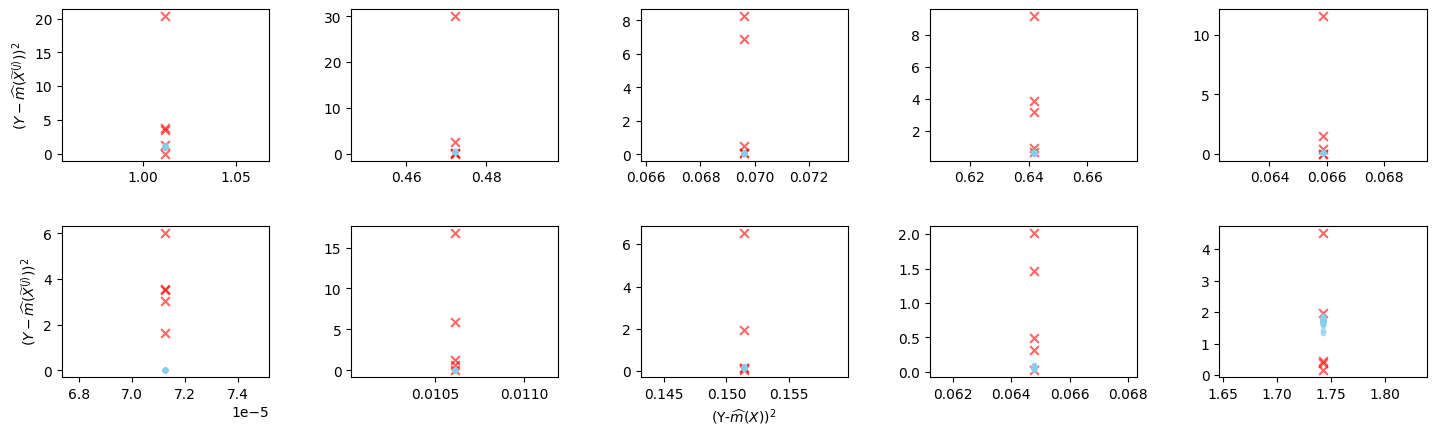

In [29]:
num_ind=10
num_cols=5
d=X_train.shape[1]

fig, axes = plt.subplots(2, 5, figsize=(15, 5))

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin500.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-lin500.csv")

# Convert DataFrames back to vectors
y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()
for j in range(d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    if j<5:
        color="red"
        marker="x"
        size=40
    else:
        color="skyblue"
        marker="o"
        size=10
    for i in range(num_ind):
        row = i // num_cols
        col = i % num_cols
        axes[row, col].scatter(((y_fitted[i]-y_test[i])**2),((y_test[i]-y_cond_fitted[i])**2),  color=color, alpha=0.6, marker=marker, s=size)
        #axes[row, col].set_title(f"Covariate {i+1}")

axes[1, 2].set_xlabel(r"(Y-$\widehat{m}(X))^2$")
axes[0, 0].set_ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")
axes[1, 0].set_ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")


# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)  # Increase padding as needed

# Save the figure
plt.savefig('visualization/plots_Angel/plots_CPI-knockoffs/cpi_knockoff_lin_d500.pdf', dpi=300)

# Show the plot
plt.show()
    

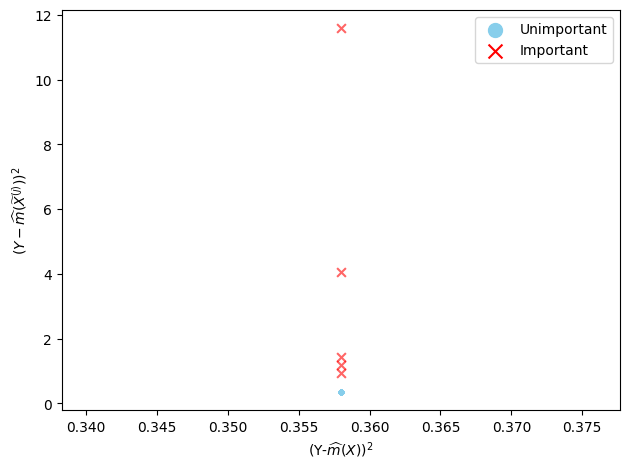

In [30]:
d=X_train.shape[1]
df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin500.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-lin500.csv")

y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()
for j in range(d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    
    if j<5:
        color="red"
        marker="x"
        size=40
    else:
        color="skyblue"
        marker="o"
        size=10
    
    plt.scatter(np.mean((y_fitted-y_test)**2),np.mean((y_test-y_cond_fitted)**2),  color=color, alpha=0.6, marker=marker, s=size)
       #axes[row, col].set_title(f"Covariate {i+1}")
        
plt.xlabel(r"(Y-$\widehat{m}(X))^2$")
plt.ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")

handles = [
    plt.scatter([], [], marker='o', color='skyblue', s=100, label='Unimportant'),
    plt.scatter([], [], marker='x', color='red', s=100, label='Important')
]

# Add the legend once with custom handles
plt.legend(handles=handles)

plt.tight_layout()  
# Save the figure
plt.savefig('visualization/plots_Angel/plots_CPI-knockoffs/cpi_knockoff_lin_d500_mean.pdf', dpi=300)

# Show the plot
plt.show()

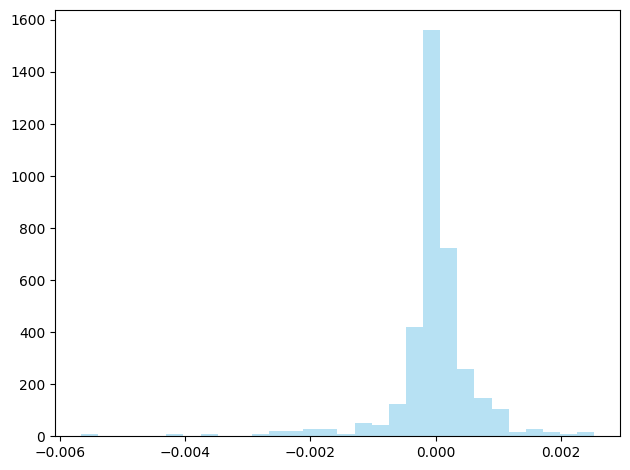

In [31]:
d=X_train.shape[1]
diff=np.zeros(d-5)

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin500.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-lin500.csv")

y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()

for j in range(5, d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    diff[j-5]=np.mean((y_test-y_cond_fitted)**2)-np.mean((y_fitted-y_test)**2)
    #axes[row, col].set_title(f"Covariate {i+1}")

plt.hist(diff,bins=30, density=True, color='skyblue', alpha=0.6 ) 
#plt.xlabel(r"(Y-$\widehat{m}(X))^2$")
#plt.ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")


# Add the legend once with custom handles
#plt.legend(handles=handles)

plt.tight_layout()  
# Save the figure
plt.savefig('cpi_knockoff_lin_d500_mean_hist.pdf', dpi=300)

# Show the plot
plt.show()

## Higher dimension

In [5]:
d=5000
X,y=GenToysDataset(n=1000, d=d, cor='toep', k=2, mu=None, rho_toep=0.6, y_method="lin")


scaler = StandardScaler()

# Fit the scaler on the training data


# Transform the test data using the same scaler
X_train_non_scaled, X_test_non_scaled, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
X_train = scaler.fit_transform(X_train_non_scaled)
X_test = scaler.transform(X_test_non_scaled)

In [6]:
modelMLP=MLPRegressor(random_state=seed)

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (50, 50), (100, 100), (50, 50, 50)],
    'activation': ['tanh', 'relu', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': ['auto', 16, 32, 64],
    'momentum': [0.9, 0.95, 0.99]  # Only relevant for 'sgd' solver
}

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  # Simplified to 3 options
    'activation': ['relu', 'tanh'],  # Focus on most common activations
    'solver': ['adam', 'sgd'],  # Keep 2 popular solvers
    'alpha': [0.0001, 0.001, 0.01],  # Narrow alpha range
    'learning_rate': ['constant', 'adaptive'],  # Focus on the most common learning rates
    'learning_rate_init': [0.001, 0.01],  # Two learning rate initialization values
    'batch_size': ['auto', 32],  # Focus on default 'auto' and a smaller value
    'momentum': [0.9, 0.95]  # Only applies to 'sgd', reduced to 2 values
}

modelMLP, MLP_score= hypertune_predictor(modelMLP, X_train, y_train, mlp_param_grid)

print("MLP score: "+str(MLP_score))
modelRF=RandomForestRegressor(random_state=seed)
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 10, 30],  
    'min_samples_split': [2, 10], 
    'min_samples_leaf': [1, 4],  
    'max_features': ['auto', 'sqrt'], 
    'bootstrap': [True] 
}



modelRF, RF_score=hypertune_predictor(modelRF, X_train, y_train, rf_param_grid)

print("RF score: "+str(RF_score))
modelGB= GradientBoostingRegressor(random_state=seed)

gb_param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'subsample': [0.8, 0.9, 1.0],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

gb_param_grid = {
    'n_estimators': [100, 300],  
    'learning_rate': [0.01, 0.1], 
    'max_depth': [3, 7], 
    'min_samples_split': [2, 10],  
    'min_samples_leaf': [1, 4],
    'subsample': [0.8, 1.0], 
    'loss': ['squared_error', 'huber']  
}


modelGB, GB_score=hypertune_predictor(modelGB, X_train, y_train, gb_param_grid)
print("GB score: "+str(GB_score))
modelxgb = XGBRegressor(random_state=seed)

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_param_grid = {
    'n_estimators': [100, 300],  # Reduced to two key values
    'learning_rate': [0.01, 0.1],  # Focus on two typical learning rates
    'max_depth': [3, 7],  # Two key depths to cover shallow and deeper trees
    'min_child_weight': [1, 5],  # Narrowed down to two values
    'subsample': [0.8, 1.0],  # Focus on two common subsample rates
    'colsample_bytree': [0.8, 1.0],  # Same for colsample_bytree
    'gamma': [0, 0.1]  # Reduced to two values for regularization
}



modelxgb, xgb_score=hypertune_predictor(modelxgb, X_train, y_train, xgb_param_grid)

print("XGB score: "+str(xgb_score))

models=[modelMLP, modelRF, modelGB, modelxgb]
scores=[MLP_score, RF_score, GB_score, xgb_score]
max_index = scores.index(max(scores))
print(max_index)
model = models[max_index]
np.mean((y_test-model.predict(X_test))**2)

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'momentum': 0.95, 'solver': 'sgd'}
MLP score: -0.0012456557315998484
Best Hyperparameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
RF score: 0.6890712223773563
Best Hyperparameters: {'learning_rate': 0.1, 'loss': 'huber', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 1.0}
GB score: 0.8174968892115735
Best Hyperparameters: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}
XGB score: 0.8226179056110803
3


0.6179895143781777

In [7]:
d=X_train.shape[1]

y_fitted=model.predict(X_test)
n_test=len(y_test)

df_y_cond_fit = np.zeros((n_test, d))
for j in range(d):
    cpi=CPI_sampler()
    cpi.fit(np.delete(X_train, j, axis=1), X_train[:,j])
    cpi.fit_res(np.delete(X_test, j, axis=1), X_test[:,j])
    X_cond=X_test.copy()
    X_cond[:,j]=cpi.sample(np.delete(X_test, j , axis=1))
    df_y_cond_fit[:, j]=model.predict(X_cond)
    

df_y_test = pd.DataFrame(y_test, columns=['y_test'])  
df_y_fitted = pd.DataFrame(y_fitted, columns=['y_fitted'])
df_y_cond_fit = pd.DataFrame(df_y_cond_fit, columns=[f'coord{i}' for i in range(d)])
# Save to CSV files
df_y_test.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_test-lin5000.csv", index=False)
df_y_fitted.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_fitted-lin5000.csv", index=False)
df_y_cond_fit.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin5000.csv", index=False)



Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'm

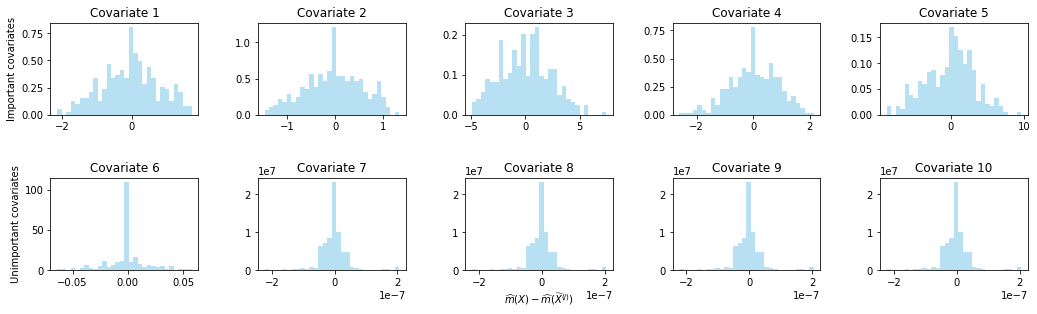

In [8]:
num_cov=10
num_cols=5
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
sign_flip=np.zeros(num_cov)

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin5000.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin5000.csv")

y_fitted = df_y_fitted.values.ravel()  

for i in range(num_cov):
    y_cond_fitted=df_y_cond_fit["coord"+str(i)]
    row = i // num_cols
    col = i % num_cols
    diff=y_fitted-y_cond_fitted
    axes[row, col].hist(diff, bins=30, density=True, color='skyblue', alpha=0.6)
    axes[row, col].set_title(f"Covariate {i+1}")
    
    eps=np.random.choice([-1, 1], size=len(diff))
    ks_statistic, p_value = ks_2samp(diff, eps*diff)
    sign_flip[i]=p_value
axes[1, 2].set_xlabel(r"$\widehat{m}(X)-\widehat{m}(\widetilde{X}^{(j)})$")
axes[0, 0].set_ylabel("Important covariates")
axes[1, 0].set_ylabel("Unimportant covariates")

# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)  # Increase padding as needed

# Save the figure
plt.savefig('histog_lin_d5000.pdf', dpi=300)

# Show the plot
plt.show()

In [9]:
sign_flip

array([0.99999788, 0.97046718, 0.94144747, 0.97046718, 0.24882478,
       0.99993245, 0.3416595 , 0.72206341, 0.99930019, 0.51826852])

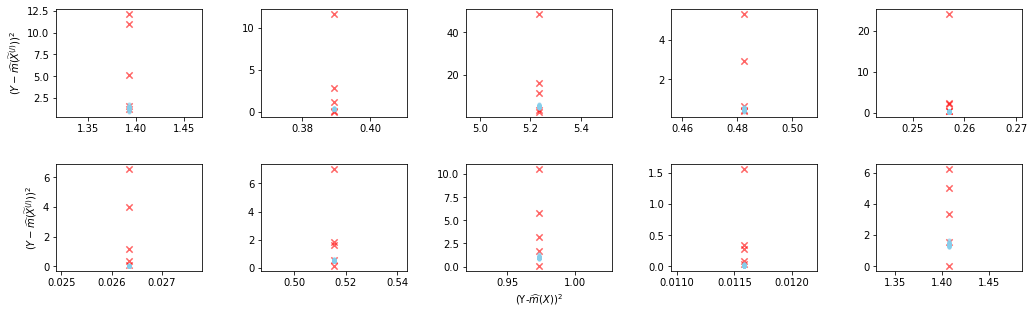

In [10]:
num_ind=10
num_cols=5
fig, axes = plt.subplots(2, 5, figsize=(15, 5))

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin5000.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin5000.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-lin5000.csv")

# Convert DataFrames back to vectors
y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()
for j in range(d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    if j<5:
        color="red"
        marker="x"
        size=40
    else:
        color="skyblue"
        marker="o"
        size=10
    for i in range(num_ind):
        row = i // num_cols
        col = i % num_cols
        axes[row, col].scatter(((y_fitted[i]-y_test[i])**2),((y_test[i]-y_cond_fitted[i])**2),  color=color, alpha=0.6, marker=marker, s=size)
        #axes[row, col].set_title(f"Covariate {i+1}")

axes[1, 2].set_xlabel(r"(Y-$\widehat{m}(X))^2$")
axes[0, 0].set_ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")
axes[1, 0].set_ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")


# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)  # Increase padding as needed

# Save the figure
plt.savefig('visualization/plots_Angel/plots_CPI-knockoffs/cpi_knockoff_lin_d5000.pdf', dpi=300)

# Show the plot
plt.show()
    

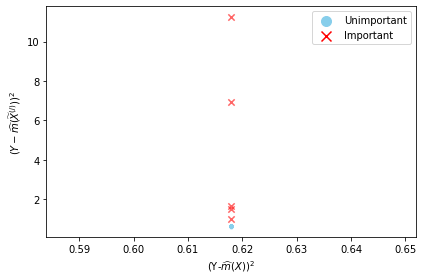

In [11]:
d=X_train.shape[1]
df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin5000.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin5000.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-lin5000.csv")

y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()
for j in range(d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    
    if j<5:
        color="red"
        marker="x"
        size=40
    else:
        color="skyblue"
        marker="o"
        size=10
    
    plt.scatter(np.mean((y_fitted-y_test)**2),np.mean((y_test-y_cond_fitted)**2),  color=color, alpha=0.6, marker=marker, s=size)
       #axes[row, col].set_title(f"Covariate {i+1}")
        
plt.xlabel(r"(Y-$\widehat{m}(X))^2$")
plt.ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")

handles = [
    plt.scatter([], [], marker='o', color='skyblue', s=100, label='Unimportant'),
    plt.scatter([], [], marker='x', color='red', s=100, label='Important')
]

# Add the legend once with custom handles
plt.legend(handles=handles)

plt.tight_layout()  
# Save the figure
plt.savefig('visualization/plots_Angel/plots_CPI-knockoffs/cpi_knockoff_lin_d5000_mean.pdf', dpi=300)

# Show the plot
plt.show()

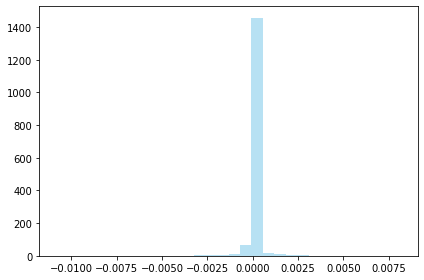

In [12]:
d=X_train.shape[1]
diff=np.zeros(d-5)

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-lin5000.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-lin5000.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-lin5000.csv")

y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()

for j in range(5, d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    diff[j-5]=np.mean((y_test-y_cond_fitted)**2)-np.mean((y_fitted-y_test)**2)
    #axes[row, col].set_title(f"Covariate {i+1}")

plt.hist(diff,bins=30, density=True, color='skyblue', alpha=0.6 ) 
#plt.xlabel(r"(Y-$\widehat{m}(X))^2$")
#plt.ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")


# Add the legend once with custom handles
#plt.legend(handles=handles)

plt.tight_layout()  
# Save the figure
plt.savefig('cpi_knockoff_lin_d5000_mean_hist.pdf', dpi=300)

# Show the plot
plt.show()

## No linear data
$y=X_0X_1\mathbb{1}_{X_2>0}+2X_3X_4\mathbb{1}_{X_2<0}$

In [13]:
d=500
X,y=GenToysDataset(n=1000, d=d, cor='toep', k=2, mu=None, rho_toep=0.6)


scaler = StandardScaler()

X_train_non_scaled, X_test_non_scaled, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
X_train = scaler.fit_transform(X_train_non_scaled)
X_test = scaler.transform(X_test_non_scaled)


In [35]:
modelMLP=MLPRegressor(random_state=seed)

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (50, 50), (100, 100), (50, 50, 50)],
    'activation': ['tanh', 'relu', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': ['auto', 16, 32, 64],
    'momentum': [0.9, 0.95, 0.99]  # Only relevant for 'sgd' solver
}

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  # Simplified to 3 options
    'activation': ['relu', 'tanh'],  # Focus on most common activations
    'solver': ['adam', 'sgd'],  # Keep 2 popular solvers
    'alpha': [0.0001, 0.001, 0.01],  # Narrow alpha range
    'learning_rate': ['constant', 'adaptive'],  # Focus on the most common learning rates
    'learning_rate_init': [0.001, 0.01],  # Two learning rate initialization values
    'batch_size': ['auto', 32],  # Focus on default 'auto' and a smaller value
    'momentum': [0.9, 0.95]  # Only applies to 'sgd', reduced to 2 values
}

modelMLP, MLP_score= hypertune_predictor(modelMLP, X_train, y_train, mlp_param_grid)

print("MLP score: "+str(MLP_score))
modelRF=RandomForestRegressor(random_state=seed)
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 10, 30],  
    'min_samples_split': [2, 10], 
    'min_samples_leaf': [1, 4],  
    'max_features': ['auto', 'sqrt'], 
    'bootstrap': [True] 
}



modelRF, RF_score=hypertune_predictor(modelRF, X_train, y_train, rf_param_grid)

print("RF score: "+str(RF_score))
modelGB= GradientBoostingRegressor(random_state=seed)

gb_param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'subsample': [0.8, 0.9, 1.0],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

gb_param_grid = {
    'n_estimators': [100, 300],  
    'learning_rate': [0.01, 0.1], 
    'max_depth': [3, 7], 
    'min_samples_split': [2, 10],  
    'min_samples_leaf': [1, 4],
    'subsample': [0.8, 1.0], 
    'loss': ['squared_error', 'huber']  
}


modelGB, GB_score=hypertune_predictor(modelGB, X_train, y_train, gb_param_grid)
print("GB score: "+str(GB_score))
modelxgb = XGBRegressor(random_state=seed)

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_param_grid = {
    'n_estimators': [100, 300],  # Reduced to two key values
    'learning_rate': [0.01, 0.1],  # Focus on two typical learning rates
    'max_depth': [3, 7],  # Two key depths to cover shallow and deeper trees
    'min_child_weight': [1, 5],  # Narrowed down to two values
    'subsample': [0.8, 1.0],  # Focus on two common subsample rates
    'colsample_bytree': [0.8, 1.0],  # Same for colsample_bytree
    'gamma': [0, 0.1]  # Reduced to two values for regularization
}



modelxgb, xgb_score=hypertune_predictor(modelxgb, X_train, y_train, xgb_param_grid)

print("XGB score: "+str(xgb_score))

models=[modelMLP, modelRF, modelGB, modelxgb]
scores=[MLP_score, RF_score, GB_score, xgb_score]
max_index = scores.index(max(scores))
print(max_index)
model = models[max_index]
np.mean((y_test-model.predict(X_test))**2)

/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization has

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'momentum': 0.95, 'solver': 'sgd'}
MLP score: 0.25215187172567616
Best Hyperparameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
RF score: 0.3286417607730762
Best Hyperparameters: {'learning_rate': 0.1, 'loss': 'huber', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 1.0}
GB score: 0.8031510256380565


/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/storage/store3/work/areyerol/miniconda3/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manyli

Best Hyperparameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 1.0}
XGB score: 0.7930807897508426
2


0.6728960255310664

In [36]:
d=X_train.shape[1]

y_fitted=model.predict(X_test)
n_test=len(y_test)

df_y_cond_fit = np.zeros((n_test, d))
for j in range(d):
    cpi=CPI_sampler()
    cpi.fit(np.delete(X_train, j, axis=1), X_train[:,j])
    cpi.fit_res(np.delete(X_test, j, axis=1), X_test[:,j])
    X_cond=X_test.copy()
    X_cond[:,j]=cpi.sample(np.delete(X_test, j , axis=1))
    df_y_cond_fit[:, j]=model.predict(X_cond)
    

df_y_test = pd.DataFrame(y_test, columns=['y_test'])  
df_y_fitted = pd.DataFrame(y_fitted, columns=['y_fitted'])
df_y_cond_fit = pd.DataFrame(df_y_cond_fit, columns=[f'coord{i}' for i in range(d)])
# Save to CSV files
df_y_test.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_test-nolin500.csv", index=False)
df_y_fitted.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_fitted-nolin500.csv", index=False)
df_y_cond_fit.to_csv(f"results/results_csv_Angel/CPI-knockoffs/y_cond_fit-nolin500.csv", index=False)

Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_

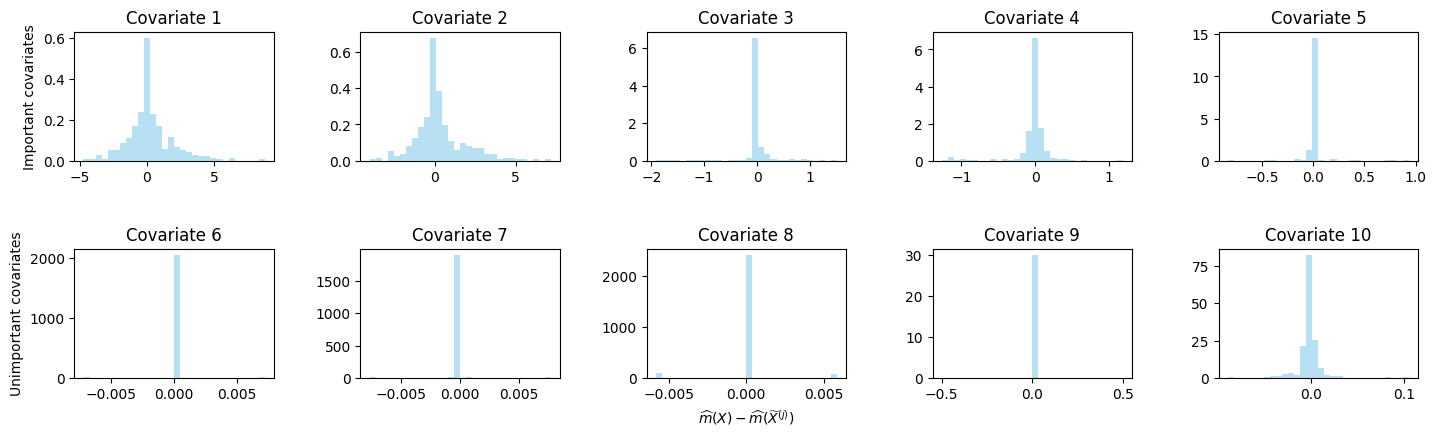

In [7]:
num_cov=10
num_cols=5
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
sign_flip=np.zeros(num_cov)

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-nolin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-nolin500.csv")

y_fitted = df_y_fitted.values.ravel()  


for i in range(num_cov):
    y_cond_fitted=df_y_cond_fit["coord"+str(i)]
    row = i // num_cols
    col = i % num_cols
    diff=y_fitted-y_cond_fitted
    axes[row, col].hist(diff, bins=30, density=True, color='skyblue', alpha=0.6)
    axes[row, col].set_title(f"Covariate {i+1}")
    
    eps=np.random.choice([-1, 1], size=len(diff))
    ks_statistic, p_value = ks_2samp(diff, eps*diff)
    sign_flip[i]=p_value
axes[1, 2].set_xlabel(r"$\widehat{m}(X)-\widehat{m}(\widetilde{X}^{(j)})$")
axes[0, 0].set_ylabel("Important covariates")
axes[1, 0].set_ylabel("Unimportant covariates")

# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)  # Increase padding as needed

# Save the figure
plt.savefig('histog_nolin_d500.pdf', dpi=300)

# Show the plot
plt.show()

In [8]:
sign_flip

array([0.94144747, 0.97046718, 0.97046718, 0.78794533, 0.84834224,
       1.        , 1.        , 1.        , 1.        , 1.        ])

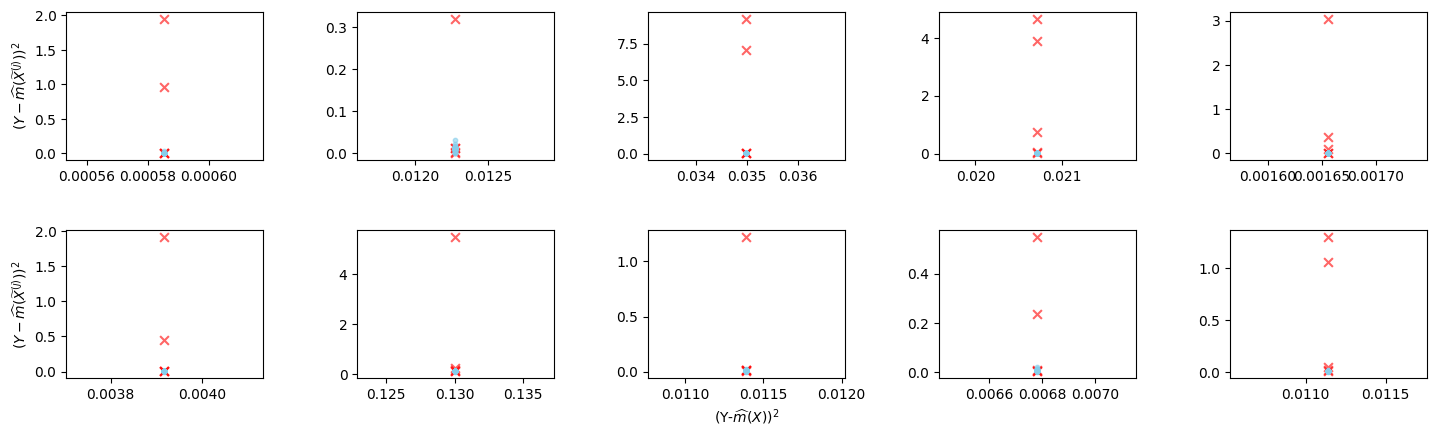

In [10]:
num_ind=10
num_cols=5
fig, axes = plt.subplots(2, 5, figsize=(15, 5))

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-nolin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-nolin500.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-nolin500.csv")


# Convert DataFrames back to vectors
y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()
for j in range(d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    if j<5:
        color="red"
        marker="x"
        size=40
    else:
        color="skyblue"
        marker="o"
        size=10
    for i in range(num_ind):
        row = i // num_cols
        col = i % num_cols
        axes[row, col].scatter(((y_fitted[i]-y_test[i])**2),((y_test[i]-y_cond_fitted[i])**2),  color=color, alpha=0.6, marker=marker, s=size)
        #axes[row, col].set_title(f"Covariate {i+1}")

axes[1, 2].set_xlabel(r"(Y-$\widehat{m}(X))^2$")
axes[0, 0].set_ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")
axes[1, 0].set_ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")


# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)  # Increase padding as needed

# Save the figure
plt.savefig('visualization/plots_Angel/plots_CPI-knockoffs/cpi_knockoff_nolin_d500.pdf', dpi=300)

# Show the plot
plt.show()
    

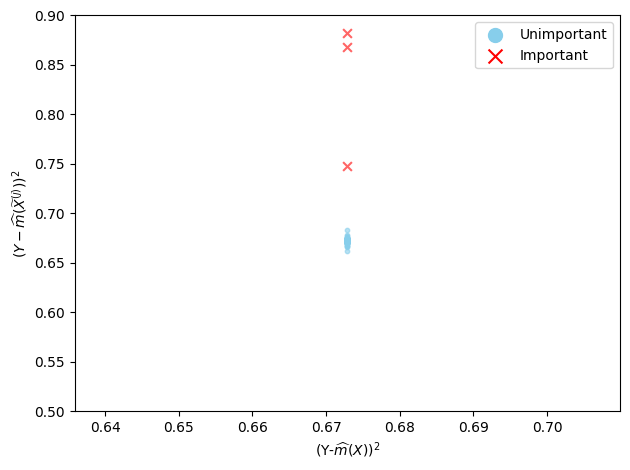

In [15]:
d=X_train.shape[1]
df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-nolin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-nolin500.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-nolin500.csv")

y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()

for j in range(d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    
    if j<5:
        color="red"
        marker="x"
        size=40
    else:
        color="skyblue"
        marker="o"
        size=10
    
    plt.scatter(np.mean((y_fitted-y_test)**2),np.mean((y_test-y_cond_fitted)**2),  color=color, alpha=0.6, marker=marker, s=size)
       #axes[row, col].set_title(f"Covariate {i+1}")
        
plt.xlabel(r"(Y-$\widehat{m}(X))^2$")
plt.ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")

handles = [
    plt.scatter([], [], marker='o', color='skyblue', s=100, label='Unimportant'),
    plt.scatter([], [], marker='x', color='red', s=100, label='Important')
]

# Add the legend once with custom handles
plt.legend(handles=handles)
plt.ylim(0.5, 0.9)
plt.tight_layout()  
# Save the figure
plt.savefig('visualization/plots_Angel/plots_CPI-knockoffs/cpi_knockoff_nolin_d500_mean.pdf', dpi=300)

# Show the plot
plt.show()

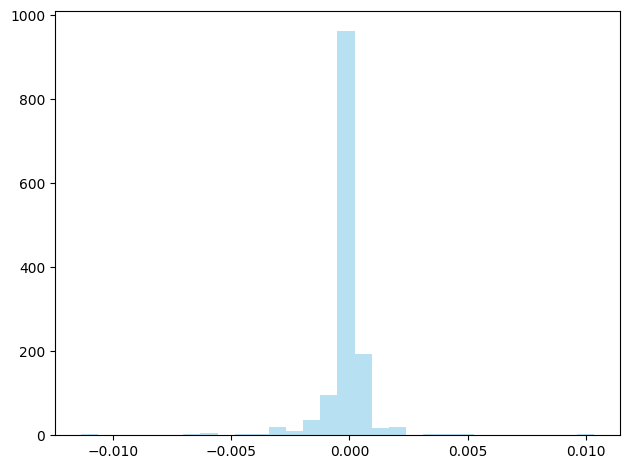

In [14]:
d=X_train.shape[1]
diff=np.zeros(d-5)

df_y_cond_fit= pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_cond_fit-nolin500.csv")
df_y_fitted = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_fitted-nolin500.csv")
df_y_test = pd.read_csv("results/results_csv_Angel/CPI-knockoffs/y_test-nolin500.csv")

y_fitted = df_y_fitted.values.ravel()  
y_test=df_y_test.values.ravel()

for j in range(5, d):
    y_cond_fitted=df_y_cond_fit["coord"+str(j)]
    diff[j-5]=np.mean((y_test-y_cond_fitted)**2)-np.mean((y_fitted-y_test)**2)
    #axes[row, col].set_title(f"Covariate {i+1}")

plt.hist(diff,bins=30, density=True, color='skyblue', alpha=0.6 ) 
#plt.xlabel(r"(Y-$\widehat{m}(X))^2$")
#plt.ylabel(r"$(Y-\widehat{m}(\widetilde{X}^{(j)}))^2$")


# Add the legend once with custom handles
#plt.legend(handles=handles)

plt.tight_layout()  
# Save the figure
plt.savefig('cpi_knockoff_nolin_d500_mean_hist.pdf', dpi=300)

# Show the plot
plt.show()